# Chapter 6: Data Loading, Storage, and File Formats

## 6.1 Reading and Writing Data in Text Format

> 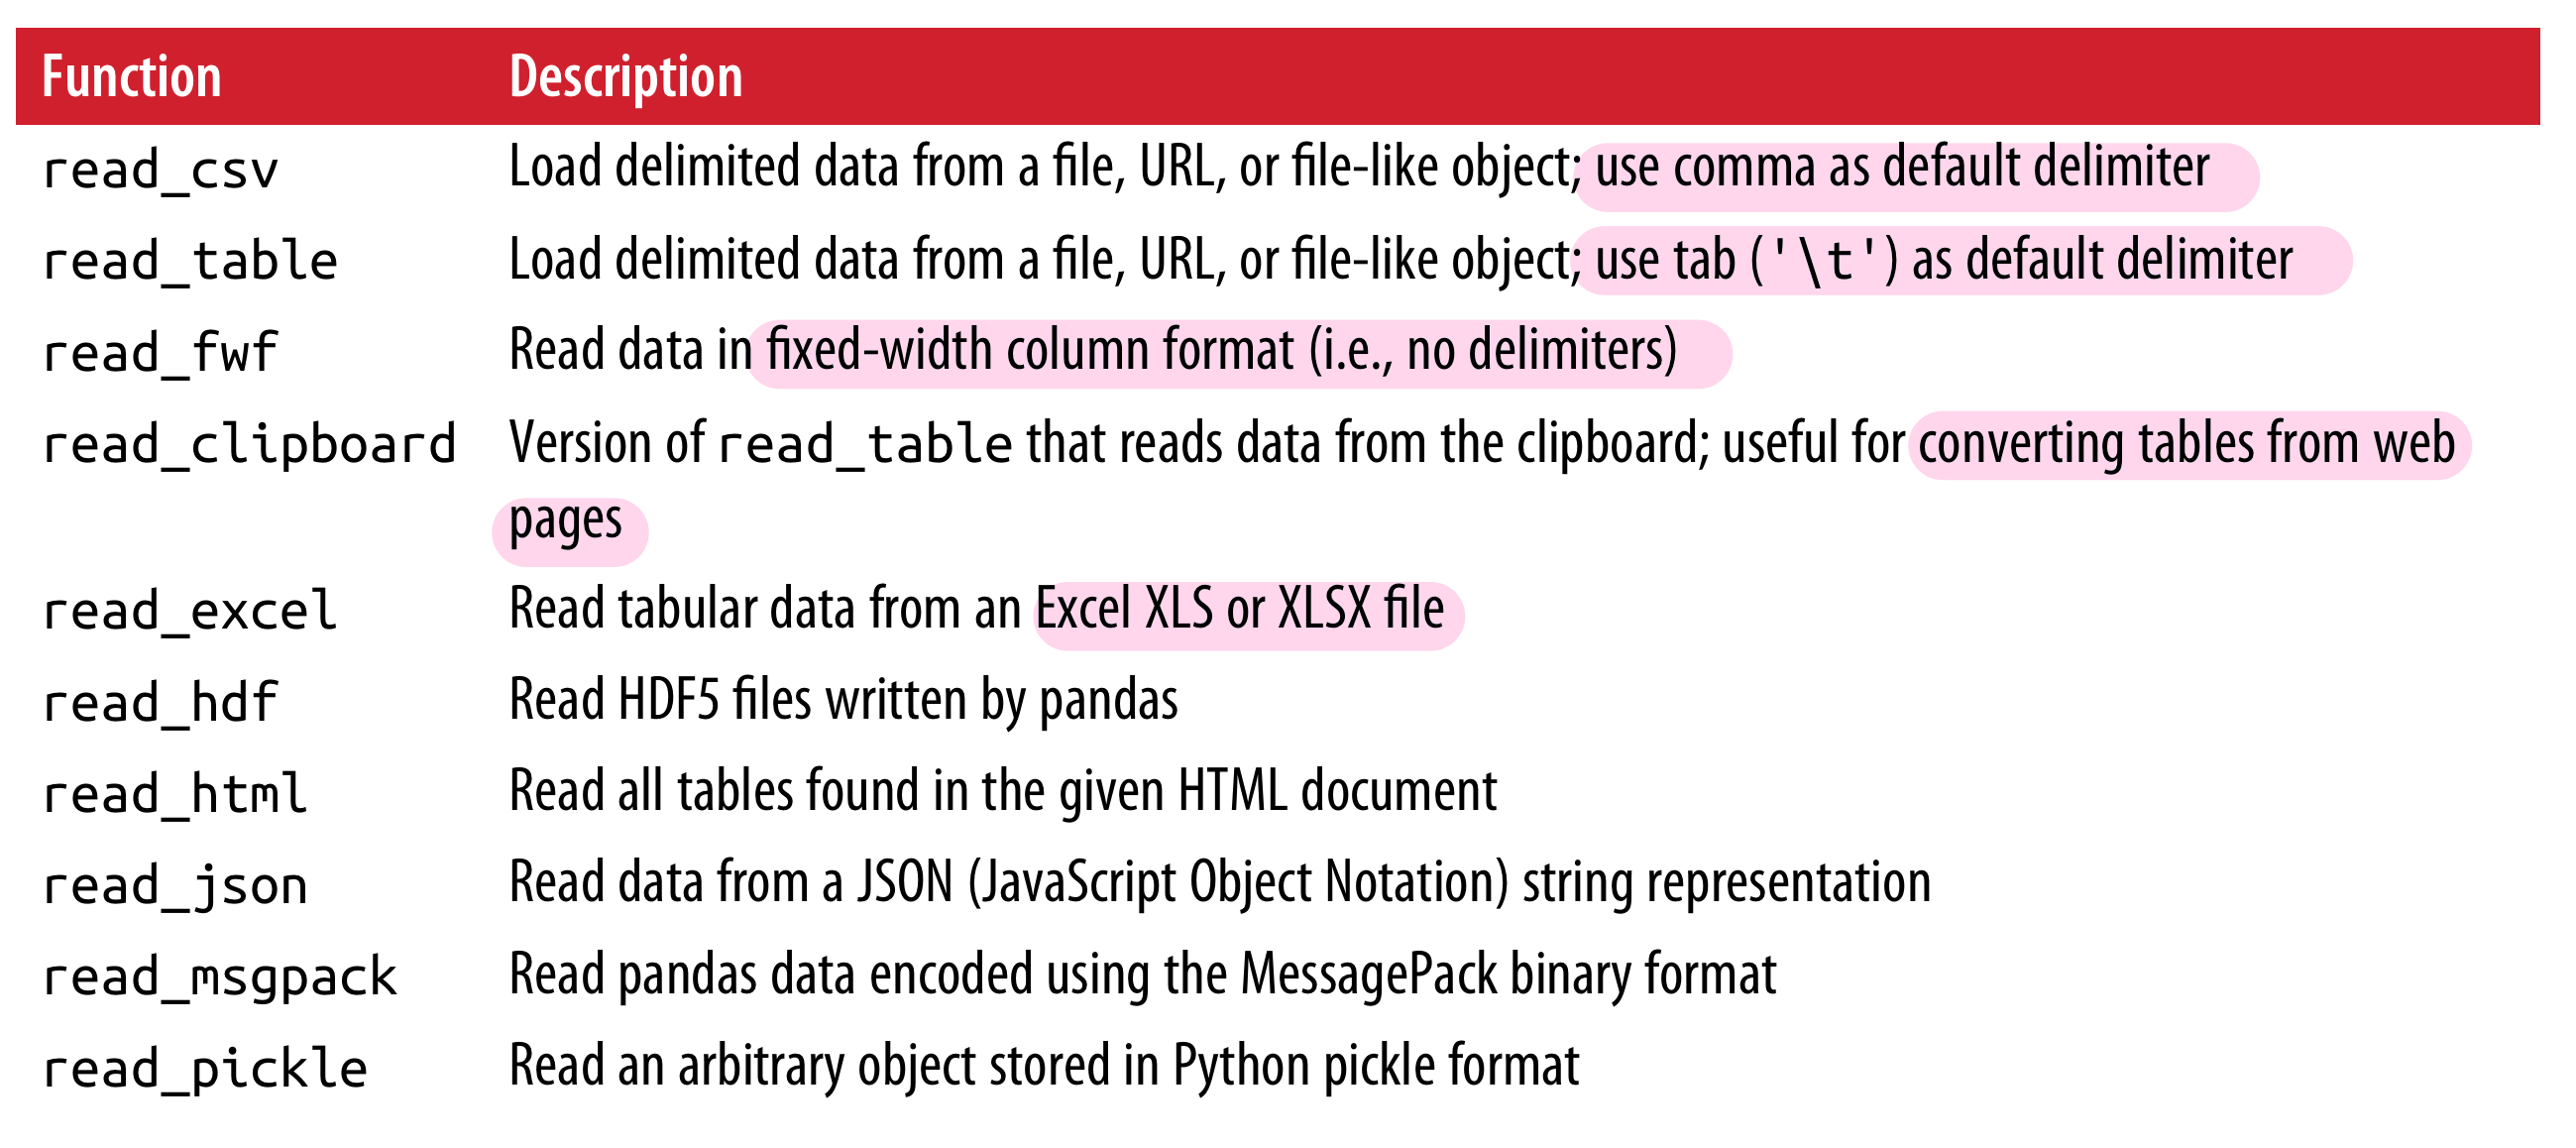
> 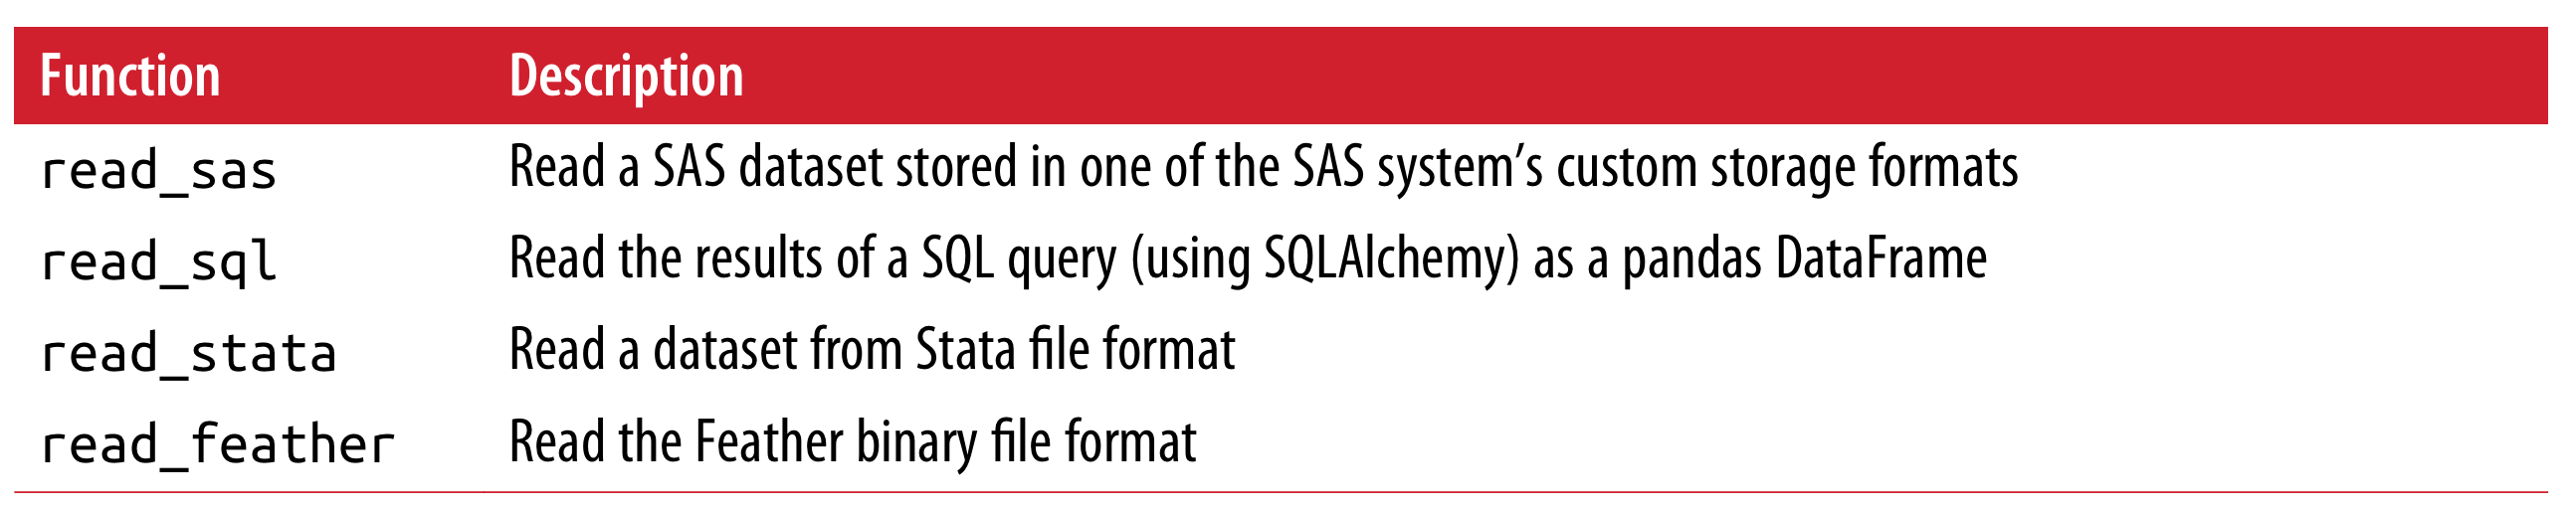

- Indexing : Can treat one or more columns as the returned DataFrame, and whether **to get column names from the file, the users, or not at all**.
- Type inference and data conversion : This includes **the user-defined value conversions** and **custom list of missing makers**.
- **Datetime parsing** : Combining data and time information spread over multiple columns into a single column in the result.
- Iterating : Support for iterating over **chunks of very large files**.
- Unclean data issues : **Skipping rows** of a footer, comments, or other minor things like numeric data with thousands separated by commas.


In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('Examples/ex1.csv')
df

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


In [3]:
# Header가 없을 경우
# 1 - 그대로 가져오기
pd.read_csv('Examples/ex2.csv', header=None)

,0,1,2,3,4
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


In [4]:
# 2 -새롭게 지정해주기
pd.read_csv('Examples/ex2.csv', names=['a','b','c','d','message'])

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


In [5]:
# 열 중에 하나를 index화
a = ['a','b','c','d','message']
pd.read_csv('Examples/ex2.csv', names=a, index_col='message') #or index_col=4

,a,b,c,d
message,,,,
hello,1,2,3,4
world,5,6,7,8
foo,9,10,11,12


In [6]:
# Hierarchical index 설정
parsed = pd.read_csv('Examples/csv_mindex.csv', index_col=['key1', 'key2'])
parsed

value1  value2
key1 key2                
one  a          1       2
     b          3       4
     c          5       6
     d          7       8
two  a          9      10
     b         11      12
     c         13      14
     d         15      16

In [7]:
# 특정 행 제거 후 불러오기
!cat Examples/ex4.csv

# hey!
a,b,c,d,message
# just wanted to make things more difficult for you
# who reads CSV files with computers, anyway?
1,2,3,4,hello
5,6,7,8,world


In [8]:
pd.read_csv('Examples/ex4.csv', skiprows=[0,2,3])

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


### Handling missing values
- By default, pandas uses a set of commonly occuring sentinels, such as **NA** and **NULL**:

In [9]:
# 사용 데이터
!cat Examples/ex5.csv

something,a,b,c,d,message
one,1,2,3,4,NA
two,5,6,,8,world


- 기본 설정 : 문자열 'NA'와 비어있는 데이터를 **missing value('*NaN*')**로 규정

In [10]:
# 기본 설정
result = pd.read_csv('Examples/ex5.csv')
result

,something,a,b,c,d,message
0,one,1,2,3.0,4,NaN
1,two,5,6,NaN,8,world
2,three,9,10,11.0,12,foo


In [11]:
pd.isna(result)

,something,a,b,c,d,message
0,False,False,False,False,False,True
1,False,False,False,True,False,False
2,False,False,False,False,False,False


In [12]:
# keep_default_na : 기본 설정을 사용할지 결정
# na_values : missing으로 처리할 문자열을 지정
result2 = pd.read_csv('Examples/ex5.csv', 
                     keep_default_na=False, #기본 설정 사용안함 
                     na_values=['NA']) #문자열 NA만 missing value로 사용
result2

,something,a,b,c,d,message
0,one,1,2,3,4,NaN
1,two,5,6,,8,world
2,three,9,10,11,12,foo


In [13]:
result2.isna()

,something,a,b,c,d,message
0,False,False,False,False,False,True
1,False,False,False,False,False,False
2,False,False,False,False,False,False


In [14]:
# Different NA sentinels can be specified for each column:
sentinels = {'message':['foo', 'NA'], 'something':['two']}
result3 = pd.read_csv('Examples/ex5.csv',
           keep_default_na=False,
           na_values=sentinels)
result3

,something,a,b,c,d,message
0,one,1,2,3,4,NaN
1,NaN,5,6,,8,world
2,three,9,10,11,12,NaN


In [15]:
pd.isna(result3)

,something,a,b,c,d,message
0,False,False,False,False,False,True
1,True,False,False,False,False,False
2,False,False,False,False,False,True


> 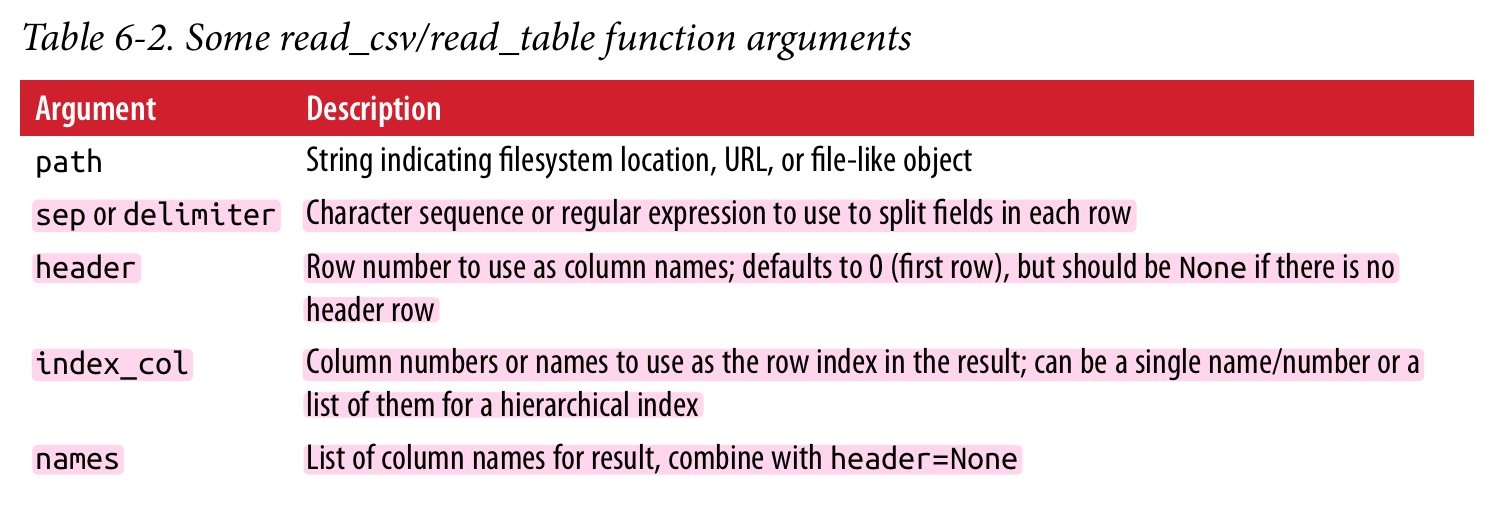
> 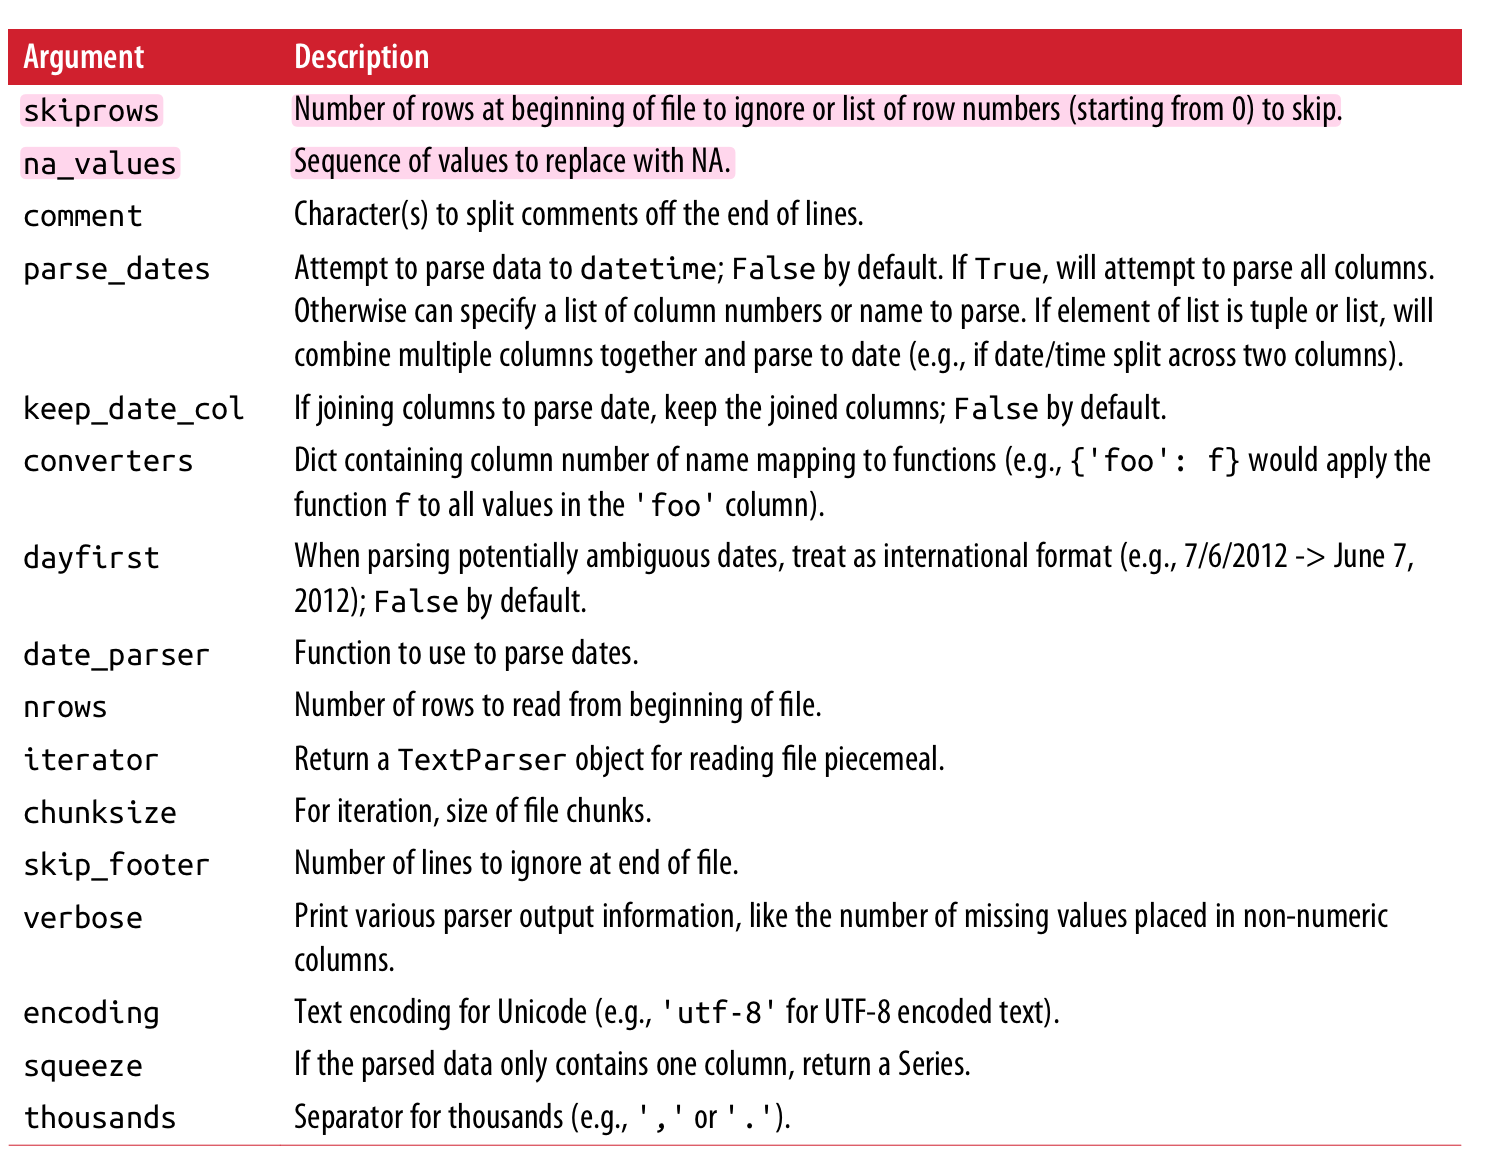

### Reading Text Files in Pieces
- When processing very large files, you may want to read only a small piece of a file or iterate through smaller chunks of the file.

In [16]:
# reading only a small number of rows
result = pd.read_csv('Examples/ex6.csv', nrows=5)
result

,one,two,three,four,key
0,0.467976,-0.038649,-0.295344,-1.824726,L
1,-0.358893,1.404453,0.704965,-0.200638,B
2,-0.501840,0.659254,-0.421691,-0.057688,G
3,0.204886,1.074134,1.388361,-0.982404,R
4,0.354628,-0.133116,0.283763,-0.837063,Q


In [17]:
# reading a file in pieces, specify a chunksize as a number of rows:
chunker = pd.read_csv('Examples/ex6.csv', chunksize=1000)
type(chunker)

pandas.io.parsers.readers.TextFileReader

In [18]:
chunker = pd.read_csv('Examples/ex6.csv', chunksize=1000)
tot = pd.Series([], dtype='int64')
for piece in chunker:
    tot = tot.add(piece['key'].value_counts(), fill_value=0)

tot = tot.sort_values(ascending=False)
tot[:10]

E    368.0
X    364.0
L    346.0
O    343.0
Q    340.0
M    338.0
J    337.0
F    335.0
K    334.0
H    330.0
dtype: float64

### Writing Data to Text Format
- Using DataFrame's ***to_csv*** method, we can write the data out to a comma-separated file(CSV):
- writing to ***sys.stdout*** so it prints the text result **to the console rather than a file**:

In [19]:
data = pd.read_csv('Examples/ex5.csv')
data

,something,a,b,c,d,message
0,one,1,2,3.0,4,NaN
1,two,5,6,NaN,8,world
2,three,9,10,11.0,12,foo


In [20]:
data.to_csv('Examples/out.csv') #delimeter => ','
!cat Examples/out.csv

,something,a,b,c,d,message
0,one,1,2,3.0,4,
1,two,5,6,,8,world
2,three,9,10,11.0,12,foo


In [21]:
import sys

data.to_csv(sys.stdout, sep='|')

|something|a|b|c|d|message
0|one|1|2|3.0|4|
1|two|5|6||8|world
2|three|9|10|11.0|12|foo


In [22]:
data.to_csv(sys.stdout, na_rep='NULL') #Missing value 대체

,something,a,b,c,d,message
0,one,1,2,3.0,4,NULL
1,two,5,6,NULL,8,world
2,three,9,10,11.0,12,foo


- Only a subset of the columns, and in an order of choosing

In [23]:
data.to_csv(sys.stdout, index=False, columns=['a','b','c'])

a,b,c
1,2,3.0
5,6,
9,10,11.0


>### Skip
>### Working with Other Delimited Formats
>### JSON Data
>### XML and HTML: Web Scraping

## 6.2 Binary Data Formats
- **Pickle**
> - One of the easiest ways to store data efficiently in binary format is using Python's built-in **pickle** serialization.
> - pandas object all have a ***to_pickle*** method that writes the data to disk in pickle format:

In [24]:
# pickle
frame = pd.read_csv('Examples/ex1.csv')
frame.to_pickle('Examples/frame_pickle')
pd.read_pickle('Examples/frame_pickle')

,a,b,c,d,message
0,1,2,3,4,hello
1,5,6,7,8,world
2,9,10,11,12,foo


- **HDF5 Format**
> - Storing large quantities of scientific array data.
> - It has interfaces available in many languages, including Java, Julia, **MATLAB**, and Python.
> - HDF5 is not a database. It is suited for **write-once, read-many datasets**. While data **can be added to a file at any time**, if multiple writers do so simultaneously, the file **can become corrupted**.

In [ ]:
frame = pd.DataFrame({'a':np.random.randn(100)})
store = pd.HDFStore('mydata.h5')
store['obj1'] = frame
store['obj1_col'] = frame['a']

In [ ]:
store.put('obj2', frame, format='table') # store['obj2'] = frame
store.select('obj2', where=['index>=10 and index<=15'])

In [ ]:
# The pandas.read_hdf function gives you a shortcut to these tools:
frame.to_hdf('mydata.h5', 'obj3', format='table')
pd.read_hdf('mydata.h5', 'obj3', where=['index<5'])

- **Microsoft Excel Files**
> - To use *ExcelFile*, create an **instance** by passing a path to an xls or xlsx file:

In [3]:
xlsx = pd.ExcelFile('Examples/ex1.xlsx') #instance
pd.read_excel(xlsx, 'Sheet1')

,Unnamed: 0,a,b,c,d,message
0,0,1,2,3,4,hello
1,1,5,6,7,8,world
2,2,9,10,11,12,foo


> - If you are reading multiple sheets in a file, then it is faster to create the *ExcelFile*, but you can also simply pass the filename to ***pandas.read_excel***:

In [4]:
frame = pd.read_excel('Examples/ex1.xlsx', 'Sheet1')
frame

,Unnamed: 0,a,b,c,d,message
0,0,1,2,3,4,hello
1,1,5,6,7,8,world
2,2,9,10,11,12,foo


> - To write pandas data to Excel format, you must first create an **ExcelWriter**, then write data to it using pandas objects' ***to_excel*** method:

In [5]:
writer = pd.ExcelWriter('Examples/ex2.xlsx')
frame.to_excel(writer, 'Sheet1')
writer.save()

> You can also pass a file path to ***to_excel*** and avoid **ExcelWriter**:

In [6]:
frame.to_excel('Examples/ex2.xlsx')

> ## Skip
> ## 6.3 Interacting with Web APIs
> ## 6.4 Interacting with Databases